In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import dateutil as dtl
import seaborn as sns
from scipy.signal import resample
import time
from functools import wraps
from statsmodels.formula.api import ols

airlines_df = pd.read_csv('archive/airlines.csv')
airports_df = pd.read_csv('archive/airports.csv')
flights_df = pd.read_csv('archive/flights.csv', dtype={'ORIGIN_AIRPORT':object,'DESTINATION_AIRPORT':object}, usecols=
                         ['YEAR','MONTH','DAY','FLIGHT_NUMBER','AIRLINE','ORIGIN_AIRPORT','DESTINATION_AIRPORT','FLIGHT_NUMBER','DEPARTURE_TIME','ARRIVAL_TIME','DEPARTURE_DELAY','DISTANCE','AIR_TIME','ARRIVAL_DELAY','CANCELLED','DIVERTED'])


In [2]:
def timer(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        func(*args, **kwargs)
        print(time.time() - start)
    return wrapper



def to_time(row):
    if pd.isna(row):return np.nan
    if int(row)==2400: row = '00:00'
    else:
        row = "{0:04d}".format(int(row))
        row = dt.time(int(row[0:2]),int(row[2:4]))
    return row
flights_df['departure_time'] = flights_df['DEPARTURE_TIME'].apply(to_time)







print(flights_df['departure_time'])
print(flights_df['departure_time'].isna().sum())






0          23:54:00
1          00:02:00
2          00:18:00
3          00:15:00
4          00:24:00
             ...   
5819074    23:55:00
5819075    23:55:00
5819076    23:50:00
5819077    23:53:00
5819078    00:14:00
Name: departure_time, Length: 5819079, dtype: object
86153


In [3]:
# print(flights_df.isna().sum())
# print(flights_df.info())

flights_df['flight_date'] = pd.to_datetime(flights_df[['YEAR','MONTH','DAY']])

# flights_df['DEPARTURE_TIME'] = pd.to_datetime(flights_df[['YEAR','MONTH','DAY','DEPARTURE_TIME']])
# flights_df['ARRIVAL_TIME'] = pd.to_datetime(flights_df[['YEAR','MONTH','DAY','ARRIVAL_TIME']])
# print(flights_df['flight_date'].head())


In [4]:
new_date_flights_df = flights_df[['flight_date','AIRLINE','ORIGIN_AIRPORT','DESTINATION_AIRPORT','FLIGHT_NUMBER','DEPARTURE_DELAY','DISTANCE','AIR_TIME','ARRIVAL_DELAY','CANCELLED','DIVERTED']]
print(new_date_flights_df.head())

  flight_date AIRLINE ORIGIN_AIRPORT DESTINATION_AIRPORT  FLIGHT_NUMBER  \
0  2015-01-01      AS            ANC                 SEA             98   
1  2015-01-01      AA            LAX                 PBI           2336   
2  2015-01-01      US            SFO                 CLT            840   
3  2015-01-01      AA            LAX                 MIA            258   
4  2015-01-01      AS            SEA                 ANC            135   

   DEPARTURE_DELAY  DISTANCE  AIR_TIME  ARRIVAL_DELAY  CANCELLED  DIVERTED  
0            -11.0      1448     169.0          -22.0          0         0  
1             -8.0      2330     263.0           -9.0          0         0  
2             -2.0      2296     266.0            5.0          0         0  
3             -5.0      2342     258.0           -9.0          0         0  
4             -1.0      1448     199.0          -21.0          0         0  


In [5]:
combined_df = pd.merge(new_date_flights_df,airlines_df,left_on='AIRLINE',right_on='IATA_CODE',how='left', suffixes=(None,'_y'))
combined_df.drop(['AIRLINE_y', 'IATA_CODE'],axis=1,inplace=True)
print(combined_df.isna().sum())

flight_date                 0
AIRLINE                     0
ORIGIN_AIRPORT              0
DESTINATION_AIRPORT         0
FLIGHT_NUMBER               0
DEPARTURE_DELAY         86153
DISTANCE                    0
AIR_TIME               105071
ARRIVAL_DELAY          105071
CANCELLED                   0
DIVERTED                    0
dtype: int64


In [6]:
print(combined_df.dtypes)

change_combined_dict = {'CANCELLED':'bool','DIVERTED':'bool', 'AIRLINE':'object'}
combined_df=combined_df.astype(change_combined_dict)
print(combined_df.dtypes)


flight_date            datetime64[us]
AIRLINE                           str
ORIGIN_AIRPORT                 object
DESTINATION_AIRPORT            object
FLIGHT_NUMBER                   int64
DEPARTURE_DELAY               float64
DISTANCE                        int64
AIR_TIME                      float64
ARRIVAL_DELAY                 float64
CANCELLED                       int64
DIVERTED                        int64
dtype: object
flight_date            datetime64[us]
AIRLINE                        object
ORIGIN_AIRPORT                 object
DESTINATION_AIRPORT            object
FLIGHT_NUMBER                   int64
DEPARTURE_DELAY               float64
DISTANCE                        int64
AIR_TIME                      float64
ARRIVAL_DELAY                 float64
CANCELLED                        bool
DIVERTED                         bool
dtype: object


In [7]:
print(combined_df.isna().sum())
cols = ['ARRIVAL_DELAY','DEPARTURE_DELAY','AIR_TIME']
combined_df[cols] = combined_df.groupby('AIRLINE')[cols]\
    .transform(lambda x: x.fillna(x.median()))
print(combined_df.isna().sum())

flight_date                 0
AIRLINE                     0
ORIGIN_AIRPORT              0
DESTINATION_AIRPORT         0
FLIGHT_NUMBER               0
DEPARTURE_DELAY         86153
DISTANCE                    0
AIR_TIME               105071
ARRIVAL_DELAY          105071
CANCELLED                   0
DIVERTED                    0
dtype: int64
flight_date            0
AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
FLIGHT_NUMBER          0
DEPARTURE_DELAY        0
DISTANCE               0
AIR_TIME               0
ARRIVAL_DELAY          0
CANCELLED              0
DIVERTED               0
dtype: int64


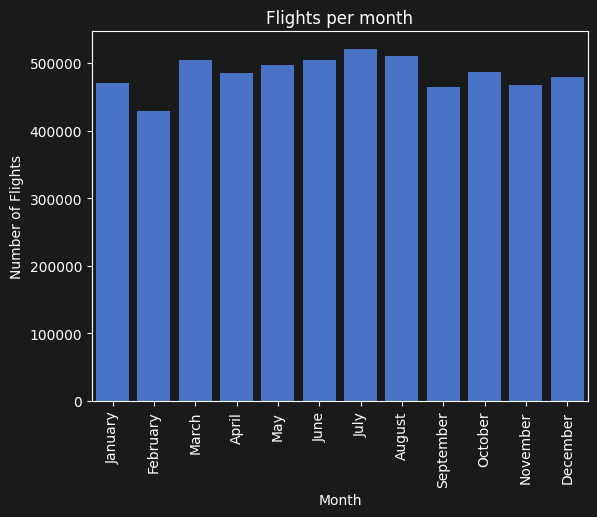

In [8]:
flights_per_month = combined_df.resample('ME', on='flight_date')['FLIGHT_NUMBER'].count()
# print(flights_per_month)
sns.barplot(x=flights_per_month.index.month_name(),y=flights_per_month.values)
plt.title('Flights per month')
plt.xlabel('Month')
plt.ylabel('Number of Flights')
plt.xticks(rotation=90)
plt.show()

In [9]:
print(combined_df['DEPARTURE_DELAY'].describe())


l_quarile = combined_df['DEPARTURE_DELAY'].quantile(0.25)
up_quartile = combined_df['DEPARTURE_DELAY'].quantile(0.75)
iqr = 1.5*(up_quartile-l_quarile)
lower = l_quarile - iqr
upper = l_quarile + iqr

outliers = combined_df.loc[(combined_df['DEPARTURE_DELAY']<lower) | (combined_df['DEPARTURE_DELAY']>upper)]
# print(outliers['DEPARTURE_DELAY'].median())
# print(lower, upper, iqr)
dep_no_outliers = combined_df.loc[~((combined_df['DEPARTURE_DELAY']<lower) | (combined_df['DEPARTURE_DELAY']>upper))]
print(dep_no_outliers['DEPARTURE_DELAY'].count()+outliers['DEPARTURE_DELAY'].count())
print(combined_df['DEPARTURE_DELAY'].count())

count    5.819079e+06
mean     9.207094e+00
std      3.682978e+01
min     -8.200000e+01
25%     -5.000000e+00
50%     -2.000000e+00
75%      7.000000e+00
max      1.988000e+03
Name: DEPARTURE_DELAY, dtype: float64
5819079
5819079


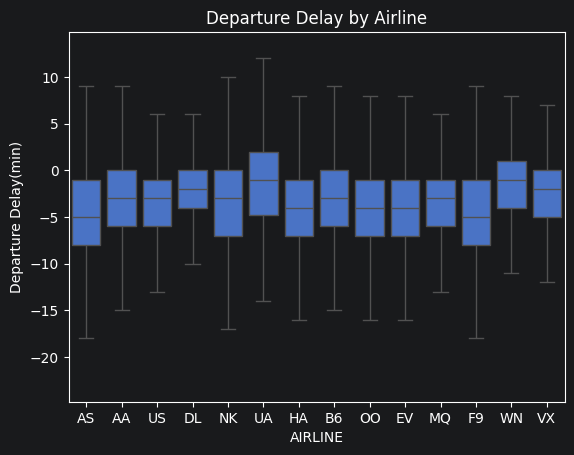

In [10]:
sns.boxplot(data=dep_no_outliers, x='AIRLINE', y='DEPARTURE_DELAY', fliersize=0)
plt.title('Departure Delay by Airline')
plt.ylabel('Departure Delay(min)')
plt.show()

In [11]:
distance = combined_df.groupby('AIRLINE')['DISTANCE'].median()


<Axes: >

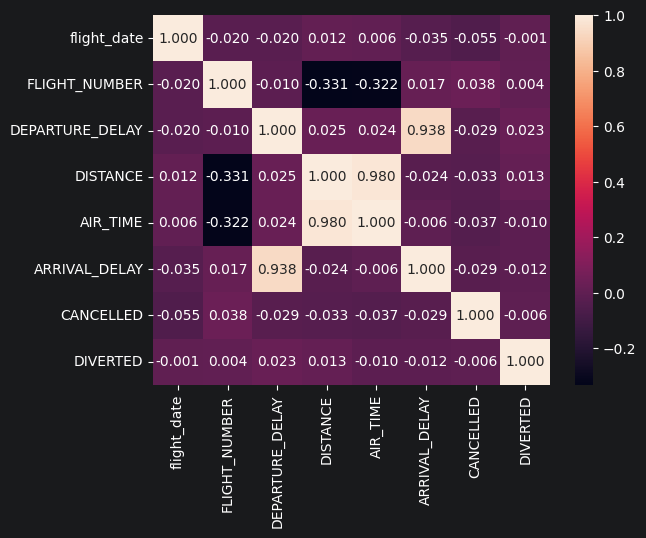

In [14]:
combined_df[['flight_date','FLIGHT_NUMBER','DEPARTURE_DELAY','DISTANCE','AIR_TIME','ARRIVAL_DELAY','CANCELLED','DIVERTED']].corr()
sns.heatmap(combined_df[['flight_date','FLIGHT_NUMBER','DEPARTURE_DELAY','DISTANCE','AIR_TIME','ARRIVAL_DELAY','CANCELLED','DIVERTED']].corr(), annot=True, fmt='.3f')